# Nashville Housing Data EDA (Post Analysis)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import textwrap

In [2]:
BLUE,CORAL,GREEN,AMBER,PURPLE,TEAL,GRAY,LIGHT = (
    "#2563EB","#DC2626","#16A34A","#D97706","#7C3AED",
    "#0891B2","#374151","#F1F5F9")
_style = ('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid'
          in plt.style.available else 'seaborn-whitegrid')
plt.style.use(_style)

In [3]:
data = pd.read_excel(r'C:\Users\hp\Desktop\Shreya\Datasets\Nashville Housing Feature Engineered Data.xlsx')

In [4]:
data["Sale Date"] = pd.to_datetime(data["Sale Date"])
DECADE_ORDER = ["Pre-1900","1900-1919","1920-1939","1940-1959",
                "1960-1979","1980-1999","2000-2009","2010-2024"]
PRICE_ORDER  = ["Budget","Mid-Range","Upper-Mid","Luxury"]
data["Decade_Built"]   = pd.Categorical(data["Decade_Built"], categories=DECADE_ORDER, ordered=True)
data["Price_Category"] = pd.Categorical(data["Price_Category"], categories=PRICE_ORDER,  ordered=True)

In [5]:
res = data[data["Bedrooms"] > 0].copy()

top5_cities = data["Property City"].value_counts().head(5).index.tolist()

### Price Landscape

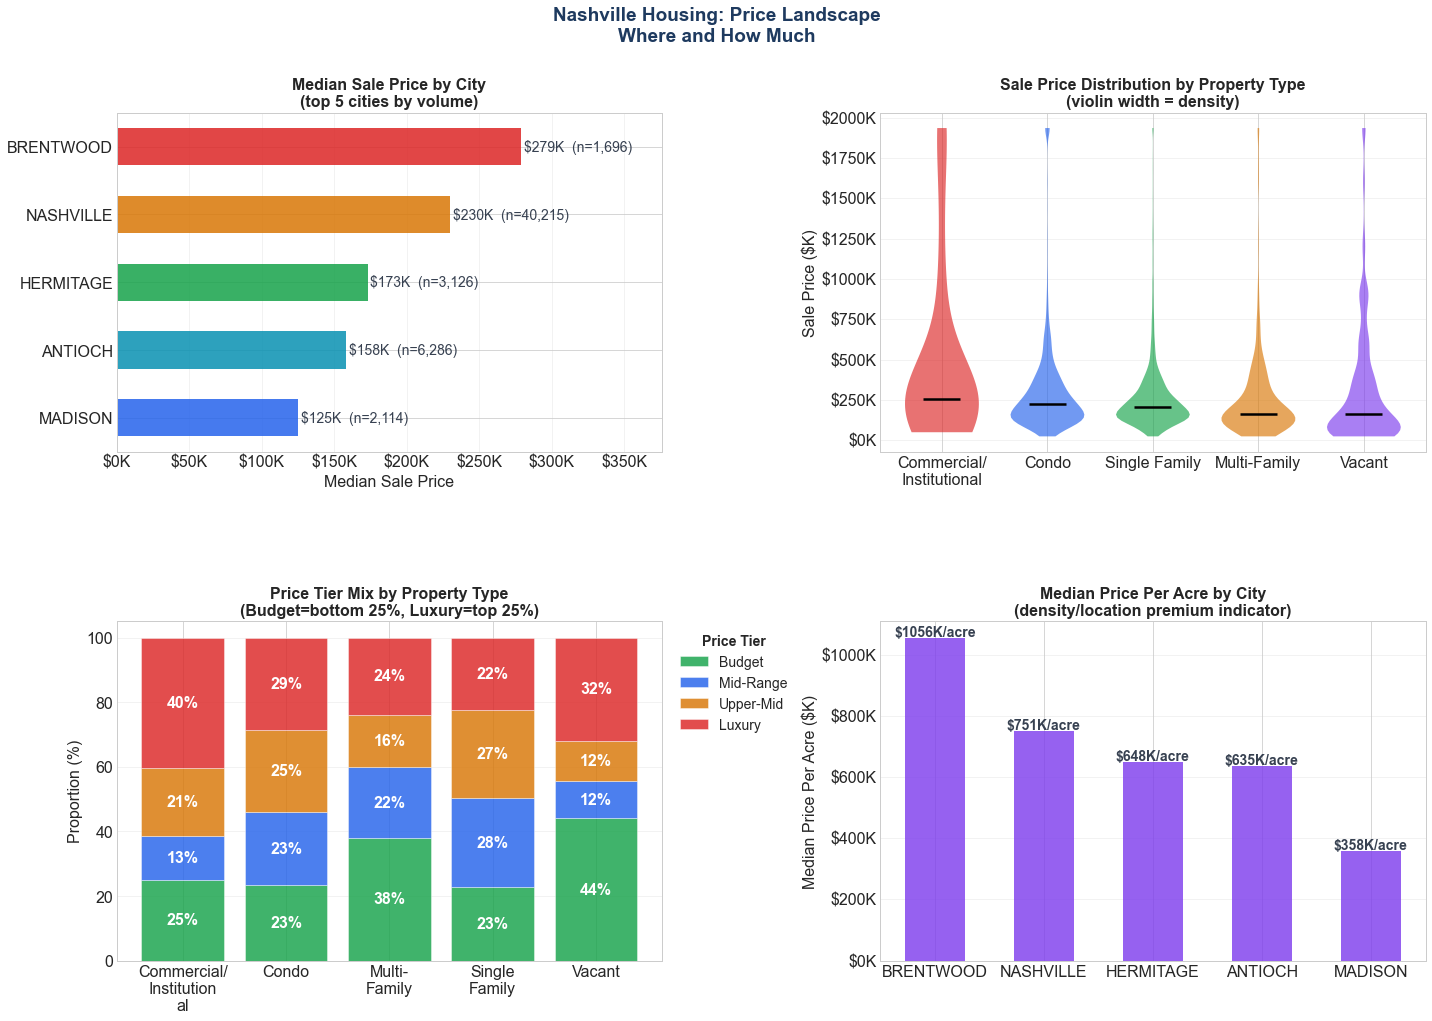

In [6]:
fig1, axes = plt.subplots(2, 2, figsize=(20, 14))
fig1.suptitle("Nashville Housing: Price Landscape\nWhere and How Much",
              fontsize=19, fontweight="bold", color="#1E3A5F", y=1.01)
 
# Panel 1: Median price by city
ax = axes[0, 0]
city_stats = (data[data["Property City"].isin(top5_cities)]
              .groupby("Property City")["Sale Price"]
              .agg(["median","count","std"])
              .sort_values("median", ascending=True))

colors_city = [BLUE, TEAL, GREEN, AMBER, CORAL]
bars = ax.barh(city_stats.index, city_stats["median"]/1000,
               color=colors_city, alpha=0.85, edgecolor="none", height=0.55)

for bar, (city, row) in zip(bars, city_stats.iterrows()):
    ax.text(bar.get_width()+2, bar.get_y()+bar.get_height()/2,
            f"${row['median']/1000:.0f}K  (n={int(row['count']):,})",
            va="center", fontsize=14, color=GRAY)
    
ax.set_title("Median Sale Price by City\n(top 5 cities by volume)",
             fontsize=16, fontweight="bold")

ax.set_xlabel("Median Sale Price", fontsize=16)
ax.tick_params(labelsize=16)
ax.grid(axis="x", alpha=0.3)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:.0f}K"))
ax.set_xlim(0, city_stats["median"].max()/1000 * 1.35)
 
# Panel 2: Sale Price distribution by Land Use Group
ax = axes[0, 1]
lu_order = (data.groupby("Land_Use_Group")["Sale Price"]
               .median().sort_values(ascending=False).index.tolist())
lu_pal = [CORAL, BLUE, GREEN, AMBER, PURPLE, "#E91E63", "#00BCD4"]

data_lu = [data[data["Land_Use_Group"]==g]["Sale Price"].values/1000 for g in lu_order]
vp = ax.violinplot(data_lu, positions=range(len(lu_order)),
                   showmedians=True, showextrema=False, widths=0.7)

for body, color in zip(vp["bodies"], lu_pal):
    body.set_facecolor(color); body.set_alpha(0.65)
vp["cmedians"].set_color("black"); vp["cmedians"].set_linewidth(2.5)

ax.set_xticks(range(len(lu_order)))
ax.set_xticklabels([g.replace("/","/\n") for g in lu_order], fontsize=16)
ax.set_title("Sale Price Distribution by Property Type\n(violin width = density)",
             fontsize=16, fontweight="bold")

ax.set_ylabel("Sale Price ($K)", fontsize = 16)
ax.tick_params(axis="both", labelsize=16)
ax.grid(axis="y", alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:.0f}K"))
 
# Panel 3: Price tier breakdown
ax = axes[1, 0]
pc_lu = (data.groupby(["Land_Use_Group","Price_Category"], observed=True)
            .size().unstack(fill_value=0))
pc_pct = pc_lu.div(pc_lu.sum(axis=1), axis=0) * 100
pc_pct = pc_pct.reindex(columns=PRICE_ORDER)

colors_tier = [GREEN, BLUE, AMBER, CORAL, "#E91E63", "#00BCD4"]
bottom = np.zeros(len(pc_pct))

for col, color in zip(PRICE_ORDER, colors_tier):
    vals = pc_pct[col].values
    bars = ax.bar(pc_pct.index, vals, bottom=bottom, color=color,
                  alpha=0.82, label=col, edgecolor="white", linewidth=0.5)
    for bar, val, bot in zip(bars, vals, bottom):
        if val > 8:
            ax.text(bar.get_x()+bar.get_width()/2, bot+val/2,
                    f"{val:.0f}%", ha="center", va="center",
                    fontsize=16, color="white", fontweight="bold")
    bottom += vals
ax.set_title("Price Tier Mix by Property Type\n"
             "(Budget=bottom 25%, Luxury=top 25%)",
             fontsize=16, fontweight="bold")

ax.set_ylabel("Proportion (%)", fontsize = 16)
ax.set_ylim(0, 105)

wrapped_labels = [textwrap.fill(label, width=11) for label in pc_pct.index]
ax.set_xticks(range(len(pc_pct)))
ax.set_xticklabels(wrapped_labels, rotation=0, ha="center", fontsize=16)

ax.tick_params(axis="both", labelsize=16) 

legend = ax.legend(title="Price Tier", fontsize=14,
                   bbox_to_anchor=(1.01, 1), loc="upper left")
legend.get_title().set_fontsize(14)                        
legend.get_title().set_fontweight("bold")

ax.grid(axis="y", alpha=0.3)
 
# Panel 4: Price per acre by city
ax = axes[1, 1]
df_ppa = data[(data["Acreage_Reliable"]==1) &
            (data["Property City"].isin(top5_cities))].copy()

ppa_stats = (df_ppa.groupby("Property City")["Price_Per_Acre"]
                   .median().sort_values(ascending=False))

bars = ax.bar(ppa_stats.index, ppa_stats.values/1000, color=PURPLE,
              alpha=0.8, edgecolor="none", width=0.55)

for bar, val in zip(bars, ppa_stats.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            f"${val/1000:.0f}K/acre", ha="center", fontsize=14, color=GRAY, fontweight="bold")
    
ax.set_title("Median Price Per Acre by City\n(density/location premium indicator)",
             fontsize=16, fontweight="bold")
ax.set_ylabel("Median Price Per Acre ($K)", fontsize = 16)
ax.tick_params(axis="both", labelsize=16) 
ax.grid(axis="y", alpha=0.3)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:.0f}K"))

 
plt.tight_layout()
plt.subplots_adjust(hspace=0.5, wspace=0.4)
plt.show()

### Market Trend 2013–2019

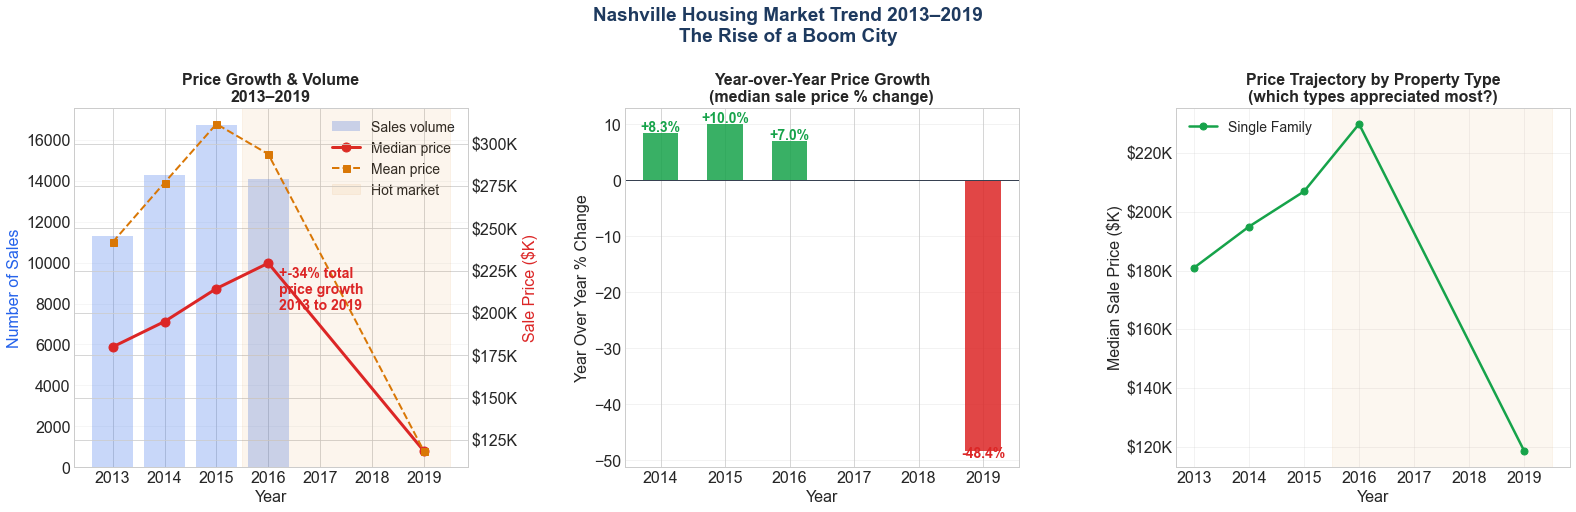

In [7]:
fig2, axes = plt.subplots(1, 3, figsize=(22, 7))
fig2.suptitle("Nashville Housing Market Trend 2013–2019\nThe Rise of a Boom City",
              fontsize=19, fontweight="bold", color="#1E3A5F", y = 1.01)
 
# Panel 1: Median price trajectory
ax = axes[0]
yearly = data.groupby("Sale_Year")["Sale Price"].agg(["median","mean","count"]).reset_index()
ax2 = ax.twinx()

ax.bar(yearly["Sale_Year"], yearly["count"], color=BLUE, alpha=0.25, label="Sales volume")
ax2.plot(yearly["Sale_Year"], yearly["median"]/1000, color=CORAL, linewidth=3,
         marker="o", markersize=9, label="Median price")

ax2.plot(yearly["Sale_Year"], yearly["mean"]/1000, color=AMBER, linewidth=2,
         marker="s", markersize=7, linestyle="--", label="Mean price")

ax2.axvspan(2015.5, 2019.5, color=AMBER, alpha=0.07, label="Hot market")
pct_change = ((yearly["median"].iloc[-1] - yearly["median"].iloc[0])
              / yearly["median"].iloc[0] * 100)

ax2.text(2016.2, yearly["median"].max()/1000 * 0.88,
         f"+{pct_change:.0f}% total\nprice growth\n2013 to 2019",
         fontsize=14, color=CORAL, fontweight="bold")

ax.set_xlabel("Year", fontsize = 16)
ax.set_ylabel("Number of Sales", color=BLUE, fontsize = 16)
ax.tick_params(axis="both", labelsize=16)

ax2.set_ylabel("Sale Price ($K)", color=CORAL, fontsize = 16)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:.0f}K"))
ax2.tick_params(axis="both", labelsize=16)

ax.set_title("Price Growth & Volume\n2013–2019", fontsize=16, fontweight="bold")
l1,lab1 = ax.get_legend_handles_labels()
l2,lab2 = ax2.get_legend_handles_labels()
ax.legend(l1+l2, lab1+lab2, fontsize=14); ax.grid(axis="y", alpha=0.2)
 
# Panel 2: YoY growth rate
ax = axes[1]
yearly["yoy_pct"] = yearly["median"].pct_change() * 100
bar_colors = [GREEN if v >= 0 else CORAL for v in yearly["yoy_pct"].fillna(0)]
bars = ax.bar(yearly["Sale_Year"][1:], yearly["yoy_pct"][1:],
              color=bar_colors[1:], alpha=0.85, edgecolor="none", width=0.55)
ax.axhline(0, color=GRAY, linewidth=1)

for bar, val in zip(bars, yearly["yoy_pct"][1:]):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+(0.3 if val>=0 else -1.2),
            f"{val:+.1f}%", ha="center", fontsize=14, fontweight="bold",
            color=GREEN if val>=0 else CORAL)
    
ax.set_title("Year-over-Year Price Growth\n(median sale price % change)",
             fontsize=16, fontweight="bold")
ax.set_xlabel("Year", fontsize = 16)
ax.set_ylabel("Year Over Year % Change", fontsize = 16)
ax.tick_params(axis="both", labelsize=16)
ax.grid(axis="y", alpha=0.3)
 
# Panel 3: Price growth by property type
ax = axes[2]
years = [2013, 2019]
for lu, color in zip(lu_order[:4], [CORAL, BLUE, GREEN, AMBER, "#E91E63", "#00BCD4"]):
    lu_yearly = (data[data["Land_Use_Group"]==lu]
                 .groupby("Sale_Year")["Sale Price"].median())
    
    if 2013 in lu_yearly.index and 2019 in lu_yearly.index:
        ax.plot(lu_yearly.index, lu_yearly.values/1000, color=color,
                linewidth=2.5, marker="o", markersize=7, label=lu)
        
ax.axvspan(2015.5, 2019.5, color=AMBER, alpha=0.06)
ax.set_title("Price Trajectory by Property Type\n(which types appreciated most?)",
             fontsize=16, fontweight="bold")

ax.set_xlabel("Year", fontsize = 16)
ax.set_ylabel("Median Sale Price ($K)", fontsize = 16)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:.0f}K"))
ax.tick_params(axis="both", labelsize=16)
ax.legend(fontsize=14)
ax.grid(alpha=0.3)
 
plt.tight_layout()
plt.subplots_adjust(hspace=0.5, wspace=0.4)
plt.show()

### Buyer Profile: What do you get at each price tier?

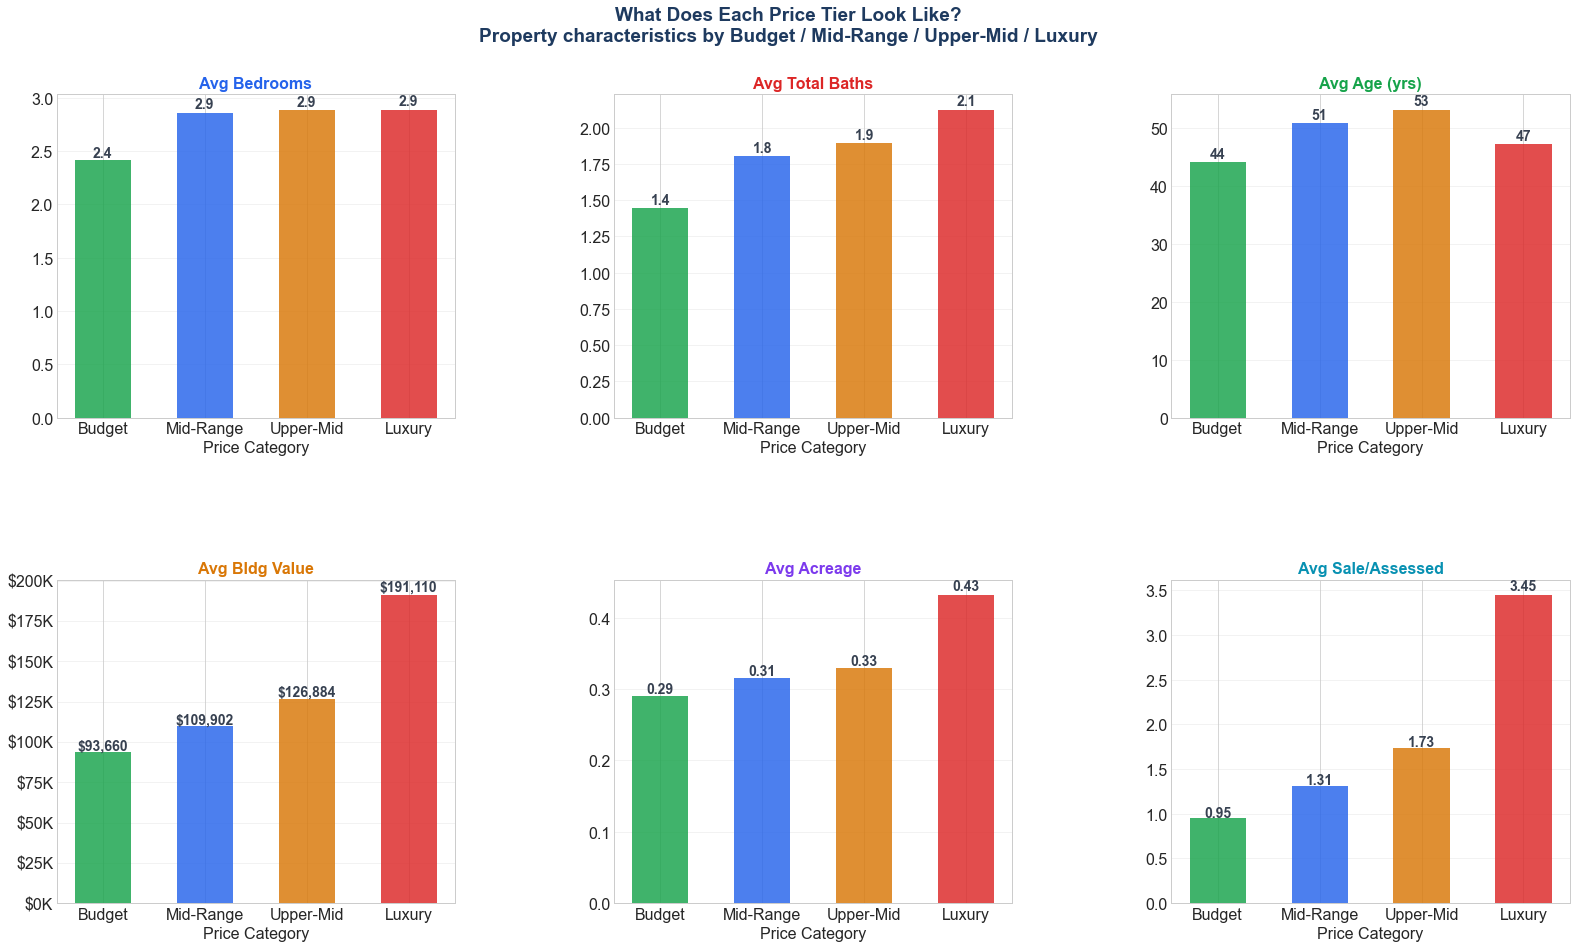

In [8]:
fig3, axes = plt.subplots(2, 3, figsize=(22, 13))
fig3.suptitle("What Does Each Price Tier Look Like?\n"
              "Property characteristics by Budget / Mid-Range / Upper-Mid / Luxury",
              fontsize=19, fontweight="bold", color="#1E3A5F", y = 1.01)
 
metrics = {
    "Bedrooms"             : ("Avg Bedrooms",   "{:.1f}",   BLUE),
    "Total_Baths"          : ("Avg Total Baths", "{:.1f}",   CORAL),
    "Property_Age"         : ("Avg Age (yrs)",   "{:.0f}",   GREEN),
    "Building Value"       : ("Avg Bldg Value",  "${:,.0f}", AMBER),
    "Acreage"              : ("Avg Acreage",     "{:.2f}",   PURPLE),
    "Sale_to_Assessed_Ratio":("Avg Sale/Assessed","{:.2f}", TEAL),
}

res_pc = data.dropna(subset=["Price_Category"])
 
for idx, (col, (label, fmt, color)) in enumerate(metrics.items()):
    ax = axes[idx // 3, idx % 3]
    stats_by_tier = res_pc.groupby("Price_Category", observed=True)[col].mean().reindex(PRICE_ORDER)
    tier_colors = [GREEN, BLUE, AMBER, CORAL, "#E91E63", "#00BCD4"]
    
    bars = ax.bar(PRICE_ORDER, stats_by_tier.values, color=tier_colors,
                  alpha=0.82, edgecolor="none", width=0.55)
    for bar, val in zip(bars, stats_by_tier.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.015,
                fmt.format(val), ha="center", fontsize=14, fontweight="bold", color=GRAY)
        
    ax.set_title(label, fontsize=16, fontweight="bold", color=color)
    ax.set_xlabel("Price Category", fontsize = 16)
    ax.tick_params(axis="both", labelsize=16)
    ax.grid(axis="y", alpha=0.3)
    
    if "Value" in col:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1e3:.0f}K"))
    ax.tick_params(axis="x", labelsize=16)

plt.tight_layout()
plt.subplots_adjust(hspace=0.5, wspace=0.4)
plt.show()

### Market price vs assessed value

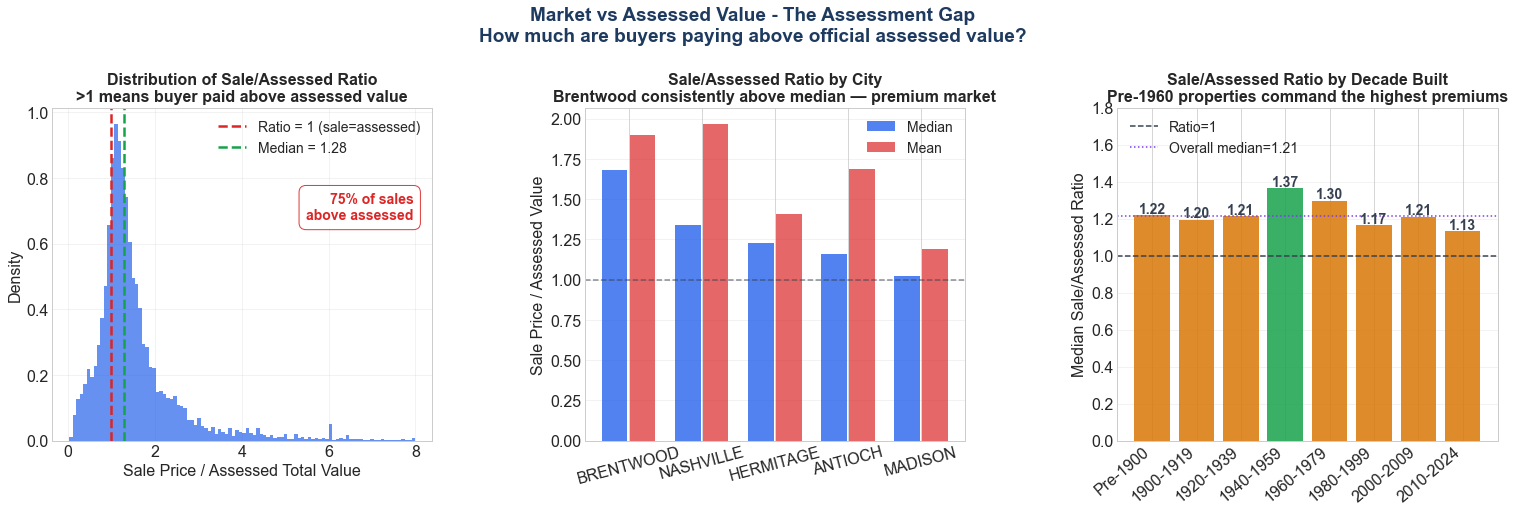

In [9]:
fig4, axes = plt.subplots(1, 3, figsize=(21, 7))
fig4.suptitle("Market vs Assessed Value - The Assessment Gap\n"
              "How much are buyers paying above official assessed value?",
              fontsize=19, fontweight="bold", color="#1E3A5F", y = 1.01)
 
# Panel 1: Distribution of Sale/Assessed ratio
ax = axes[0]
ratio = data["Sale_to_Assessed_Ratio"].dropna()
ratio = ratio[(ratio > 0) & (ratio < 8)]
ax.hist(ratio, bins=100, color=BLUE, alpha=0.7, edgecolor="none", density=True)
ax.axvline(1.0, color=CORAL, linewidth=2.5, linestyle="--", label="Ratio = 1 (sale=assessed)")
ax.axvline(ratio.median(), color=GREEN, linewidth=2.5,
           linestyle="--", label=f"Median = {ratio.median():.2f}")

above = (ratio > 1).mean() * 100

ax.text(0.95, 0.70, f"{above:.0f}% of sales\nabove assessed",
        transform=ax.transAxes, fontsize=14, color=CORAL, fontweight="bold",
        ha='right', va='center', 
        bbox=dict(boxstyle="round,pad=0.5", facecolor='white', alpha=0.9, edgecolor=CORAL))

ax.set_title("Distribution of Sale/Assessed Ratio\n"
             ">1 means buyer paid above assessed value",
             fontsize=16, fontweight="bold")
ax.set_xlabel("Sale Price / Assessed Total Value", fontsize = 16)
ax.set_ylabel("Density", fontsize = 16)
ax.legend(fontsize=14)
ax.tick_params(axis="both", labelsize=16)
ax.grid(alpha=0.3)
 
# Panel 2: Ratio by city
ax = axes[1]
city_ratio = (data[data["Property City"].isin(top5_cities)]
              .groupby("Property City")["Sale_to_Assessed_Ratio"]
              .agg(["median","mean"])
              .sort_values("median", ascending=False))
x = range(len(city_ratio))
ax.bar(x, city_ratio["median"], color=BLUE, alpha=0.8, width=0.35, label="Median", align="center")
ax.bar([i+0.38 for i in x], city_ratio["mean"], color=CORAL, alpha=0.7,
       width=0.35, label="Mean", align="center")
ax.axhline(1.0, color=GRAY, linewidth=1.5, linestyle="--", alpha=0.6)
ax.set_xticks([i+0.19 for i in x])
ax.set_xticklabels(city_ratio.index, rotation=15, fontsize=16)
ax.set_title("Sale/Assessed Ratio by City\n"
             "Brentwood consistently above median — premium market",
             fontsize=16, fontweight="bold")
ax.set_ylabel("Sale Price / Assessed Value", fontsize = 16)
ax.tick_params(axis="both", labelsize=16)
ax.legend(fontsize=14)
ax.grid(axis="y", alpha=0.3)
 
# Panel 3: Ratio by decade built
ax = axes[2]
decade_ratio = (res.groupby("Decade_Built", observed=True)["Sale_to_Assessed_Ratio"]
                   .median().reindex(DECADE_ORDER).dropna())
colors_d = [GREEN if v > 1.3 else (AMBER if v > 1.0 else CORAL) for v in decade_ratio.values]
bars = ax.bar(range(len(decade_ratio)), decade_ratio.values,
              color=colors_d, alpha=0.85, edgecolor="none")
ax.axhline(1.0, color=GRAY, linewidth=1.5, linestyle="--", label="Ratio=1")
ax.axhline(decade_ratio.median(), color=PURPLE, linewidth=1.5,
           linestyle=":", label=f"Overall median={decade_ratio.median():.2f}")
for bar, val in zip(bars, decade_ratio.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{val:.2f}", ha="center", fontsize=14, fontweight="bold", color=GRAY)
    
ax.set_xticks(range(len(decade_ratio)))
ax.set_xticklabels(decade_ratio.index, rotation=40, ha="right", fontsize=16)
ax.set_title("Sale/Assessed Ratio by Decade Built\n"
             "Pre-1960 properties command the highest premiums",
             fontsize=16, fontweight="bold")
ax.set_ylabel("Median Sale/Assessed Ratio", fontsize = 16)
ax.legend(fontsize=14, loc = "upper left")
ax.tick_params(axis="both", labelsize=16)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0.0, 1.8)
 
plt.tight_layout()
plt.subplots_adjust(hspace=0.5, wspace=0.4)

plt.show()